<a href="https://colab.research.google.com/github/5star55/EDA-Exercise/blob/main/Feature_binning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
from sklearn import preprocessing

In [6]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
df=pd.read_csv('/content/drive/MyDrive/Learning-data-analytics/Churn_Modelling.csv')

In [10]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [15]:
df.drop(columns=['RowNumber', 'CustomerId','Surname'], inplace=True, axis=1)

In [16]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [17]:
df['Age'].min()

18

In [18]:
df['Age'].mean()

np.float64(38.9218)

In [20]:
df[df['Exited']==1]['Age'].mean()

np.float64(44.8379970544919)

In [21]:
df[df['Exited']==0]['Age'].mean()

np.float64(37.40838879819164)

In [22]:
df['Age'].max()

92

In [24]:
labels=['0-21','21-41','41-61','Above 61']
bins=[0,21,41,61,100]
df['Age_bins']=pd.cut(df.Age,bins,labels=labels,include_lowest=True)

In [25]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Age_bins
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,41-61
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,21-41
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,41-61
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,21-41
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,41-61


Text(0.5, 1.0, 'Age Distribution')

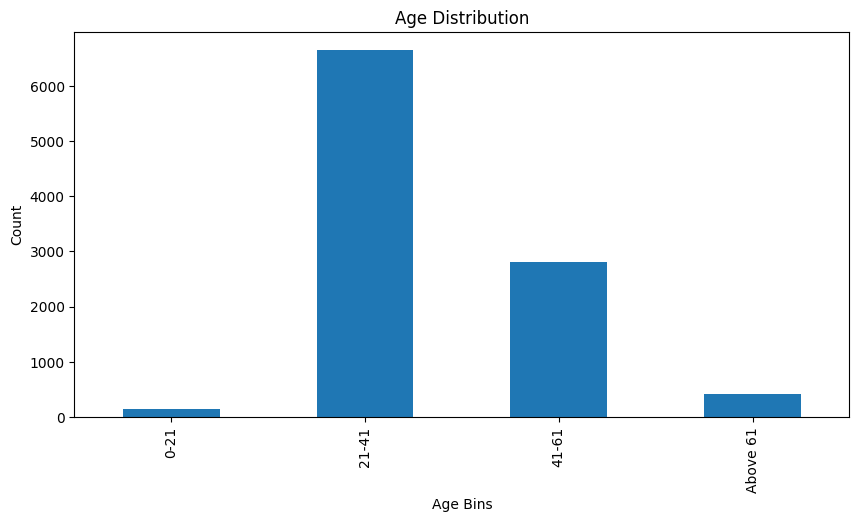

In [30]:
df['Age_bins'].value_counts().sort_index(ascending=True).plot(kind='bar',figsize=(10,5))
plt.xlabel('Age Bins')
plt.ylabel('Count')
plt.title('Age Distribution')

In [31]:
df['Age_bins'].value_counts()

,count
Age_bins,
21-41,6643
41-61,2804
Above 61,411
0-21,142
